In [1]:
import typing
import pickle
import itertools
import contextlib
import os
import pathlib
import shutil
import subprocess
import argparse
import platform
import asyncio
import pathlib
import shutil
import ctypes
import json

SCRIPT_PATH = pathlib.Path(os.path.abspath('/home/user/university/masters_second_semester_software_engineering_methodology/lab1/main.ipynb'))
SCRIPT_DIR = SCRIPT_PATH.parent
BUILD_DIR = SCRIPT_DIR / 'build'

def needs_rebuild(output_path: pathlib.Path | str, input_paths: typing.Iterable[pathlib.Path | str]) -> bool:
    if not os.path.exists(output_path):
        res = True
    else:
        output_stat = os.stat(output_path)
        res = any(os.stat(input_path).st_mtime > output_stat.st_mtime for input_path in input_paths)
    if res:
        print(f'build: {output_path}')
    return res

def clean_command():
    shutil.rmtree(BUILD_DIR, ignore_errors=True)

# async def seq_cmd(*args: str | pathlib.Path, check: bool=True, **kwargs: typing.Any) -> tuple[bytes, bytes]:
#     print('cmd: ', args)
#     if check:
#         if process.returncode
#         assert process.returncode == 0
#     return stdout, stderr


class Author(typing.NamedTuple):
    login: str
    id: str | None
    name: str | None
    is_bot: bool
    
    @classmethod
    def deserialize(cls, data: dict[typing.Any, typing.Any]) -> typing.Self:
        return cls(
            login=data['login'],
            id=data.get('id'),
            name=data.get('name'),
            is_bot=data['is_bot'],
        )

class Comment(typing.NamedTuple):
    id: str
    author: Author
    authorAssociation: str
    body: str
    createdAt: str
    includesCreatedEdit: bool
    isMinimized: bool
    minimizedReason: str
    reactionGroups: list
    url: str
    viewerDidAuthor: bool

class Commit(typing.NamedTuple):
    authoredDate: str
    authors: list[Author]
    committedDate: str
    messageBody: str
    messageHeadline: str
    oid: str

# ({'id': 'PRR_kwDODI8QW87kNtEP', 'author': {'login': 'isuffix'}, 'authorAssociation': 'COLLABORATOR', 'body': '', 'submittedAt': '2026-02-19T22:09:17Z', 'includesCreatedEdit': False, 'reactionGroups': [], 'state': 'COMMENTED', 'commit': {'oid': 'cab0a5b784a21ffd4f01b99d3caf76511ea3badd'}},)
# [{'content': 'THUMBS_UP', 'users': {'totalCount': 2}}, {'content': 'HEART', 'users': {'totalCount': 2}}]

class ReviewReactionGroupUsers(typing.NamedTuple):
    totalCount: int

class ReviewReactionGroup(typing.NamedTuple):
    content: str
    users: ReviewReactionGroupUsers

    @classmethod
    def deserialize(cls, data: dict[typing.Any, typing.Any]) -> typing.Self:
        return cls(
            content=data['content'],
            users=ReviewReactionGroupUsers(**data['users']),
        )

class ReviewAuthor(typing.NamedTuple):
    login: str

class ReviewCommit(typing.NamedTuple):
    oid: str

class Review(typing.NamedTuple):
    id: str
    author: ReviewAuthor
    authorAssociation: str
    body: str
    submittedAt: str
    includesCreatedEdit: bool
    reactionGroups: tuple[ReviewReactionGroup, ...]
    state: str
    commit: ReviewCommit

    @classmethod
    def deserialize(cls, data: dict[typing.Any, typing.Any]) -> typing.Self:
        return cls(
            id=data['id'],
            author=ReviewAuthor(**data['author']),
            authorAssociation=data['authorAssociation'],
            body=data['body'],
            submittedAt=data['submittedAt'],
            includesCreatedEdit=data['includesCreatedEdit'],
            reactionGroups=tuple(ReviewReactionGroup.deserialize(c) for c in data['reactionGroups']),
            state=data['state'],
            commit=ReviewCommit(**data['commit']),
        )

# ({'id': 'LA_kwDODI8QW88AAAABPfG87A', 'name': 'math', 'description': 'Related to math syntax, layout, etc.', 'color': '007AFF'}, {'id': 'LA_kwDODI8QW88AAAAB8X2QTw', 'name': 'interface', 'description': "PRs that add to or change Typst's user-facing interface as opposed to internals or docs changes.", 'color': 'a4ebe7'})

class PrLabel(typing.NamedTuple):
    id: str
    name: str
    description: str
    color: str

class PullRequest(typing.NamedTuple):
    additions: int
    author: Author
    changedFiles: int
    closedAt: str
    comments: tuple[Comment, ...]
    commits: tuple[Commit, ...]
    createdAt: str
    deletions: int
    labels: tuple[PrLabel, ...]
    mergedAt: str
    number: int
    reviewDecision: str
    reviews: tuple[Review, ...]
    title: str

def deserialize(data: dict[typing.Any, typing.Any]) -> PullRequest:
    return PullRequest(
        additions=data['additions'],
        author=Author.deserialize(data['author']),
        changedFiles=data['changedFiles'],
        closedAt=data['closedAt'],
        comments=tuple(Comment(**c) for c in data['comments']),
        commits=tuple(Commit(**c) for c in data['commits']),
        createdAt=data['createdAt'],
        deletions=data['deletions'],
        labels=tuple(PrLabel(**c) for c in data['labels']),
        mergedAt=data['mergedAt'],
        number=data['number'],
        reviewDecision=data['reviewDecision'],
        reviews=tuple(Review.deserialize(c) for c in data['reviews']),
        title=data['title'],
    )

class PrBlob(typing.NamedTuple):
    prs: tuple[PullRequest, ...]


BUILD_DIR.mkdir(exist_ok=True)
target_dir = SCRIPT_DIR.parent.parent / 'typst'
pr_list_path = BUILD_DIR / 'pr_list.json'
if needs_rebuild(pr_list_path, ()):
# if True:
    cmd = ("gh", "pr", "list", "--state", "all", "--limit", "5000", "--json", "number")
    print(f'{cmd=}')
    process = await asyncio.create_subprocess_exec(*cmd, cwd=target_dir, stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE)
    stdout, stderr = await process.communicate()
    assert process.returncode == 0
    stdout = stdout.decode()
    with open(pr_list_path, 'w') as fileio:
        fileio.write(stdout)
    pr_list = json.loads(stdout)
else:
    with open(pr_list_path) as fileio:
        pr_list = json.load(fileio)

pr_numbers = tuple(int(pr["number"]) for pr in pr_list)
pr_paths = tuple(BUILD_DIR / f'pr_view_{number}.json' for number in pr_numbers)
pr_rebuilds = ((number, path) for number, path in zip(pr_numbers, pr_paths) if needs_rebuild(path, ()))

is_pulled_new_prs = False
for pr_batch in itertools.batched(pr_rebuilds, 100):
    async with asyncio.TaskGroup() as tg:
        async def tg_task(number: int, pr_path: pathlib.Path):
            global is_pulled_new_prs
            cmd = ("gh", "pr", "view", str(number), "--json", "number,title,author,additions,deletions,changedFiles,createdAt,mergedAt,closedAt,reviewDecision,comments,commits,reviews,labels")
            print(f'{cmd=}')
            process = await asyncio.subprocess.create_subprocess_exec(*cmd, cwd=target_dir, stdout=asyncio.subprocess.PIPE, stderr=asyncio.subprocess.PIPE,)
            stdout, stderr = await process.communicate()
            if process.returncode != 0:
                print(f'pr {number} failed with error: {process.returncode}, {stderr.decode()=}')
            else:
                stdout = stdout.decode()
                with open(pr_path, 'w') as fileio:
                    fileio.write(stdout)
                is_pulled_new_prs = True

        for i, pr in pr_batch:
            tg.create_task(tg_task(i, pr))
    await asyncio.sleep(0.5)

if is_pulled_new_prs:
# if True:
    ser_prs_list: list[PullRequest] = []
    for pr in pr_paths:
        with open(pr) as fileio:
            data = json.load(fileio)
        ser_prs_list.append(deserialize(data))
    ser_prs = PrBlob(tuple(ser_prs_list))
    
    with open(BUILD_DIR / 'ser_prs.pickle', 'wb') as fileio:
        pickle.dump(ser_prs, fileio)

with open(BUILD_DIR / 'ser_prs.pickle', 'rb') as fileio:
    ser_prs = pickle.load(fileio)
    assert isinstance(ser_prs, PrBlob)

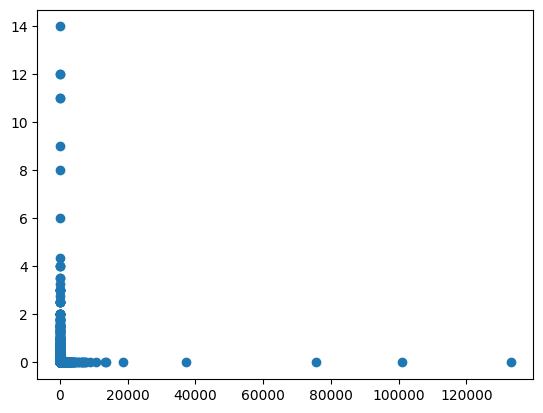

In [2]:
import numpy as np
import matplotlib.pyplot as plt

size_list: list[int] = []
density_list: list[float] = []

for pr in ser_prs.prs:
    size = pr.additions + pr.deletions
    if size == 0:
        continue
    density = len(pr.comments) / size
    size_list.append(size)
    density_list.append(density)

plt.scatter(size_list, density_list)

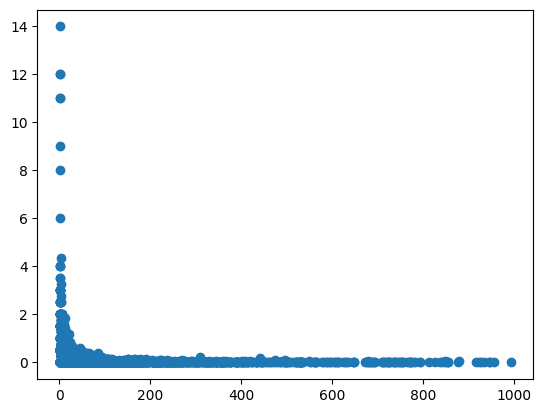

np.float64(-0.15109664884922144)

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

size_list: list[int] = []
density_list: list[float] = []

for pr in ser_prs.prs:
    size = pr.additions + pr.deletions
    if size == 0 or size > 1000:
        continue
    density = len(pr.comments) / size
    size_list.append(size)
    density_list.append(density)

plt.scatter(size_list, density_list)
plt.show()

corr_size_density, p_value1 = scipy.stats.pearsonr(size_list, density_list)
corr_size_density

Кореляція (Size vs Density): -0.1511 (p-value: 4.7187e-15)
Кореляція (Files vs Comments): 0.0419 (p-value: 2.6730e-02)


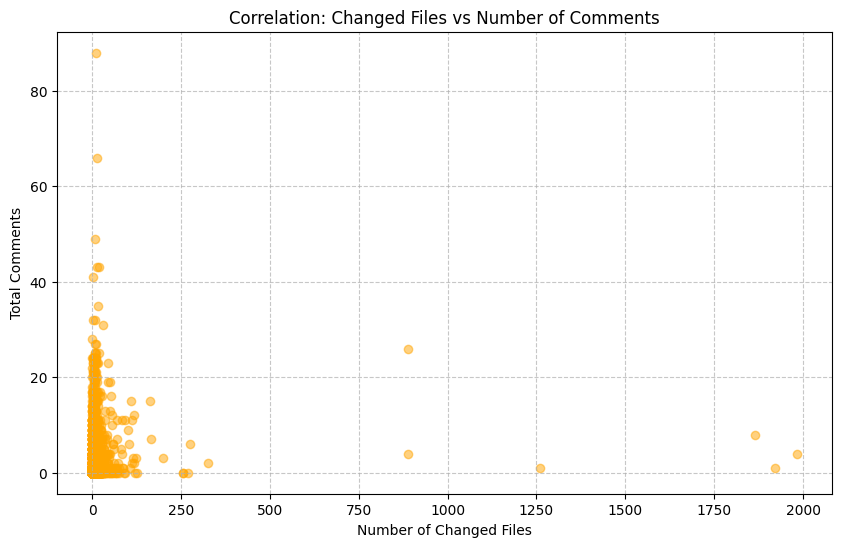

In [14]:
files_list = tuple(pr.changedFiles for pr in ser_prs.prs)
comments_count_list = tuple(len(pr.comments) for pr in ser_prs.prs)

corr_files_comments, p_value2 = scipy.stats.pearsonr(files_list, comments_count_list)

print(f"Кореляція (Size vs Density): {corr_size_density:.4f} (p-value: {p_value1:.4e})")
print(f"Кореляція (Files vs Comments): {corr_files_comments:.4f} (p-value: {p_value2:.4e})")

plt.figure(figsize=(10, 6))
plt.scatter(files_list, comments_count_list, alpha=0.5, color='orange')
plt.title('Correlation: Changed Files vs Number of Comments')
plt.xlabel('Number of Changed Files')
plt.ylabel('Total Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Кореляція (Size vs Density): -0.1511 (p-value: 4.7187e-15)
Кореляція (Files vs Comments): 0.1053 (p-value: 2.7338e-08)


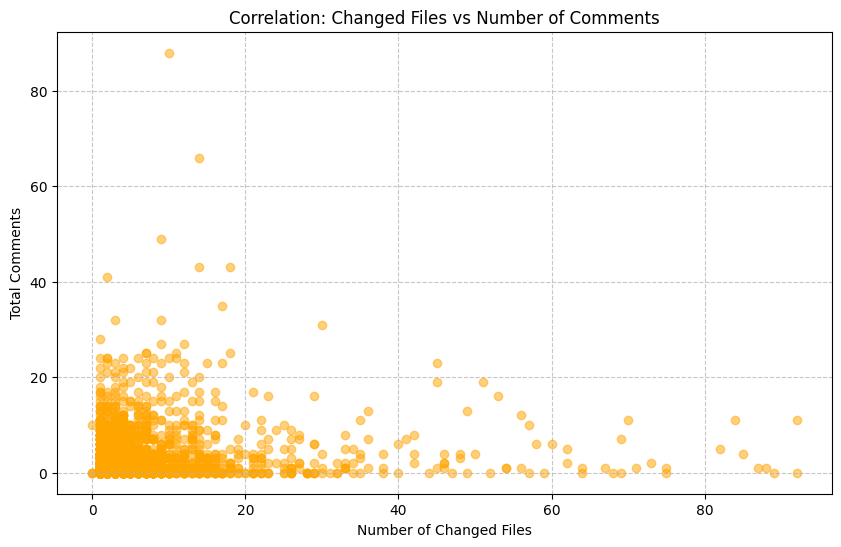

In [17]:
files_list: list[int] = []
comments_count_list: list[int] = []

for pr in ser_prs.prs:
    if pr.changedFiles < 100:
        files_list.append(pr.changedFiles)
        comments_count_list.append(len(pr.comments))

corr_files_comments, p_value2 = scipy.stats.pearsonr(files_list, comments_count_list)

print(f"Кореляція (Size vs Density): {corr_size_density:.4f} (p-value: {p_value1:.4e})")
print(f"Кореляція (Files vs Comments): {corr_files_comments:.4f} (p-value: {p_value2:.4e})")

plt.figure(figsize=(10, 6))
plt.scatter(files_list, comments_count_list, alpha=0.5, color='orange')
plt.title('Correlation: Changed Files vs Number of Comments')
plt.xlabel('Number of Changed Files')
plt.ylabel('Total Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()